## Linker length based on AF2 models

Purpose: establish the relationship between Calpha distance and linker length in number of amino acid residues to design appropriate linker length to graft GS linkers in the gaps in domain sequence

Method: 
- Evaluate AF2 database using mdtraj.dssp to identify loops ('C' in simplified DSSP code)
- For each loop, measure pairwise distance in both sequence space and in Calpha real space
- Plot the relationship between sequence length and Calpha distance
- Establish a function that returns the average peptide length in sequence for a given distance between terminal Calphas

In [37]:
import os
import pandas as pd

# Define paths to AF2 database and domainome info
afdb_pdb_dir = "/work/lpdi/users/shxiao/masif_seed/masif/data/masif_human_proteome_domains_merged/input_pdbs/compressed"

# list all files with .pdb extension in afdb_pdb_dir
pdb_files = [f for f in os.listdir(afdb_pdb_dir) if f.endswith('.pdb')]


In [2]:
f"{afdb_pdb_dir}/{pdb_files[0]}"

'/work/lpdi/users/shxiao/masif_seed/masif/data/masif_human_proteome_domains_merged/input_pdbs/compressed/AF-P10911-F1-model_v4.pdb'

In [3]:
# Determine secondary structure from DSSP
import mdtraj
import numpy as np

# load the first pdb file
pdb_file = pdb_files[0]
pdb_path = os.path.join(afdb_pdb_dir, pdb_file)

# load the pdb file
traj = mdtraj.load_pdb(pdb_path)

# determine secondary structure
dssp = mdtraj.compute_dssp(traj)

dssp

/home/ymeng/miniconda3/envs/MaSIF/lib/python3.11/site-packages/mdtraj/formats/pdb/pdbfile.py:208: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


array([['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'H',
        'H', 'H', 'C', 'H', 'H', 'H', 'C', 'C', 'C', 'C', 'C', 'C', 'C',
        'E', 'E', 'E', 'E', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H',
        'H', 'H', 'H', 'H', 'H', 'H', 'H', 'C', 'C', 'C', 'C', 'C', 'C',
        'C', 'C', 'C', 'C', 'C', 'E', 'E', 'E', 'E', 'C', 'C', 'H', 'H',
        'H', 'H', 'H', 'H', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'C', 'H',
        'H', 'H', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H',
        'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H',
        'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H',
        'H', 'H', 'H', 'H', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H',
        'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H',
        'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H',
        'H', 'H', 'H', 'H', 'H', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C',
        'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H'

In [4]:
# Function to identify continuous segments of 'C' in dssp, filtered by min_length, returning 1-based residue numbers
def get_loop_segments(dssp, min_length=3):
    """
    Identify continuous stretches (segments) of 'C' secondary structure (coil/loop)
    in the dssp result from MDTraj that are at least min_length long.

    dssp: np.ndarray or similar, shape (n_residues,) or (1, n_residues)
    Returns: list of lists of 1-based residue numbers, each with len >= min_length
    """
    # Flatten if necessary (handle shape like (1, N))
    dssp_arr = dssp
    if hasattr(dssp, "ndim") and dssp.ndim > 1:
        dssp_arr = dssp.flatten()

    segments = []
    current_segment = []
    for i, ss in enumerate(dssp_arr):
        # ss might be a numpy str type - convert to str to compare safely
        if str(ss) == 'C':
            current_segment.append(i + 1)  # 1-based residue number
        else:
            if current_segment:
                if len(current_segment) >= min_length:
                    segments.append(current_segment)
                current_segment = []
    # Don't forget the last one
    if current_segment and len(current_segment) >= min_length:
        segments.append(current_segment)
    return segments

loop_segments = get_loop_segments(dssp)
loop_segments


[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [20, 21, 22, 23, 24, 25, 26],
 [31, 32, 33, 34],
 [47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57],
 [70, 71, 72],
 [81, 82, 83, 84, 85, 86, 87],
 [122, 123, 124, 125, 126, 127],
 [162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174],
 [244, 245, 246, 247, 248, 249, 250],
 [288, 289, 290, 291, 292],
 [353, 354, 355],
 [378, 379, 380],
 [389, 390, 391, 392, 393],
 [426,
  427,
  428,
  429,
  430,
  431,
  432,
  433,
  434,
  435,
  436,
  437,
  438,
  439,
  440,
  441,
  442,
  443,
  444,
  445,
  446,
  447,
  448,
  449,
  450,
  451,
  452,
  453,
  454,
  455,
  456,
  457,
  458,
  459,
  460,
  461,
  462,
  463,
  464,
  465,
  466,
  467,
  468,
  469,
  470,
  471,
  472,
  473,
  474,
  475,
  476,
  477,
  478,
  479,
  480,
  481,
  482,
  483,
  484,
  485,
  486,
  487],
 [524, 525, 526, 527],
 [566, 567, 568, 569, 570],
 [580, 581, 582, 583],
 [606, 607, 608],
 [619, 620, 621, 622, 623, 624],
 [649, 650, 651, 652, 65

In [22]:
chain = 0
resid = 1

# Function to return the coordinates and residue numbers of all CA atoms in a chain
def get_calpha_coords_and_resSeq(traj, chain):
    sel = f"chainid {chain} and name CA"
    atom_indices = traj.topology.select(sel)
    resSeq = [traj.topology.atom(i).residue.resSeq for i in atom_indices]
    atom_coords = traj.xyz[:, atom_indices, :][0] * 10
    return atom_coords, resSeq

atom_coords, resSeq = get_calpha_coords_and_resSeq(traj, 0)
print(atom_coords)
print(resSeq)

[[-61.465996  -14.388      47.393997 ]
 [-62.327     -17.275      44.981    ]
 [-65.878     -18.68       44.554    ]
 ...
 [  2.255      26.252998    6.304    ]
 [  5.987      26.585       5.4189997]
 [  7.316      23.925       3.1330001]]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 17

In [24]:
# Compute pairwise distance in sequence space and in Calpha real space for each loop
loop = loop_segments[0]

import matplotlib.pyplot as plt

# Function to return the distance in sequence space between two residues
def seq_dist_fn(resi1, resi2):
    return abs(resi1 - resi2) + 1

# Function to measure the distance in Calpha real space between two residues
def calpha_dist_fn(atom_coords, resi1, resi2):
    resi1_coords = atom_coords[resi1-1]
    resi2_coords = atom_coords[resi2-1]
    return np.linalg.norm(resi1_coords - resi2_coords)

print(seq_dist_fn(loop[0], loop[1]))
print(calpha_dist_fn(atom_coords, loop[0], loop[1]))


2
3.8598778


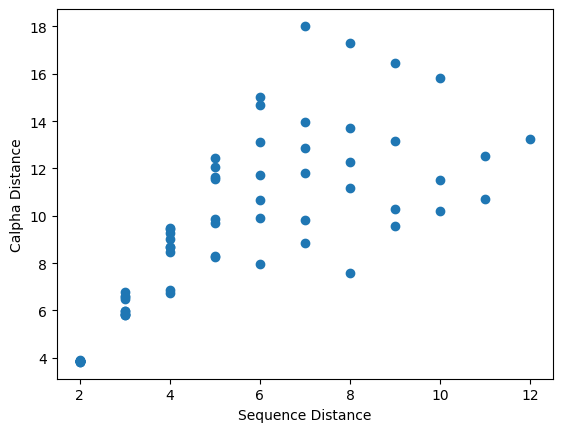

In [28]:
def compute_pairwise_seq_and_calpha_distances(atom_coords, loop, max_length=None):
    """
    Computes pairwise sequence and Calpha distances for all unique pairs in a loop.

    Parameters
    ----------
    atom_coords : array-like, shape (n_residues, 3)
        The coordinates of the CA atoms.
    loop : list of int
        List of residue numbers (1-based) in the loop.
    max_length : int, optional
        Maximum length of the loop in number of residues to consider. If None, all pairs are considered.

    Returns
    -------
    df_dist : pd.DataFrame
        Dataframe with columns: resi1, resi2, seq_dist, calpha_dist
    """
    df_dist = pd.DataFrame()
    for i in range(len(loop)):
        for j in range(i+1, len(loop)):
            resi1 = int(loop[i])
            resi2 = int(loop[j])
            seq_dist = seq_dist_fn(resi1, resi2)
            if max_length is not None and seq_dist > max_length: # skip if seq_dist is greater than max_length
                continue
            calpha_dist = calpha_dist_fn(atom_coords, resi1, resi2)
            row = pd.Series({'resi1': resi1, 'resi2': resi2, 'seq_dist': seq_dist, 'calpha_dist': calpha_dist})
            df_dist = pd.concat([df_dist, pd.DataFrame([row])], ignore_index=True)
    return df_dist

loop = loop_segments[0]
df_dist = compute_pairwise_seq_and_calpha_distances(atom_coords, loop)

# Plot the relationship between sequence length and Calpha distance
plt.scatter(df_dist['seq_dist'], df_dist['calpha_dist'])
plt.xlabel('Sequence Distance')
plt.ylabel('Calpha Distance')
plt.show()


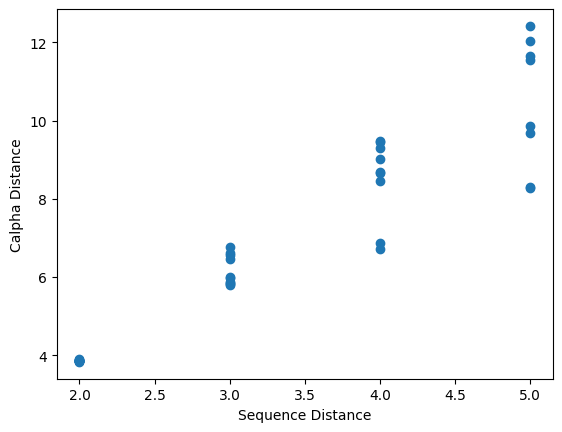

In [29]:
# proof of concept to limit the loop length to save computation
df_dist = compute_pairwise_seq_and_calpha_distances(atom_coords, loop, 5)

# Plot the relationship between sequence length and Calpha distance
plt.scatter(df_dist['seq_dist'], df_dist['calpha_dist'])
plt.xlabel('Sequence Distance')
plt.ylabel('Calpha Distance')
plt.show()

In [32]:
# Compute the pairwise distance in sequence space and in Calpha real space for all loops in the traj
df_dist_all = pd.DataFrame()
for loop in loop_segments:
    df_dist = compute_pairwise_seq_and_calpha_distances(atom_coords, loop)
    df_dist_all = pd.concat([df_dist_all, df_dist])

df_dist_all

,resi1,resi2,seq_dist,calpha_dist
0,1.0,2.0,2.0,3.859878
1,1.0,3.0,3.0,6.778836
2,1.0,4.0,4.0,9.443464
3,1.0,5.0,5.0,12.423033
4,1.0,6.0,6.0,15.033315
...,...,...,...,...
3823,922.0,924.0,3.0,5.767986
3824,922.0,925.0,4.0,9.190784
3825,923.0,924.0,2.0,3.849841
3826,923.0,925.0,3.0,6.410034


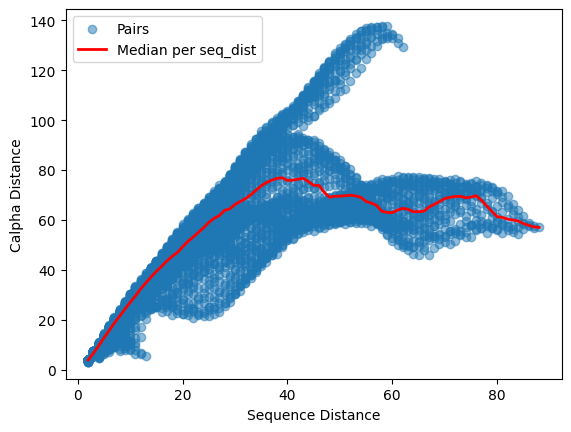

In [33]:
# Plot the relationship between sequence length and Calpha distance with median line
plt.scatter(df_dist_all['seq_dist'], df_dist_all['calpha_dist'], alpha=0.5, label='Pairs')

# Compute median calpha_dist for each seq_dist
median_per_seq_dist = df_dist_all.groupby('seq_dist')['calpha_dist'].median().reset_index()

# Plot the median line
plt.plot(median_per_seq_dist['seq_dist'], median_per_seq_dist['calpha_dist'], 
         color='red', linewidth=2, label='Median per seq_dist')

plt.xlabel('Sequence Distance')
plt.ylabel('Calpha Distance')
plt.legend()
plt.show()


In [49]:
median_per_seq_dist

,seq_dist,calpha_dist
0,2.0,3.844175
1,3.0,6.558963
2,4.0,9.557896
3,5.0,12.666997
4,6.0,15.702197
...,...,...
82,84.0,59.589695
83,85.0,58.503347
84,86.0,57.859619
85,87.0,57.171753


In [4]:
import py3Dmol

# visualize the first pdb file
pdb_file = pdb_files[0]
pdb_path = os.path.join(afdb_pdb_dir, pdb_file)

# load the pdb file
view = py3Dmol.view(data=open(pdb_path).read())
view.setStyle({'cartoon': {'color': 'lightgrey'}})
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

__________
### Full-workflow to compute linker length distribution on 200 random AFDB structures

In [ ]:
# Use tqdm to show progress bar and update every 10 files.
from tqdm import tqdm
import warnings

# Set max_length to 40 because loops that are too long are irrelevant
max_length = 40

# 1. Select 200 random AFDB structures
seed = 42
np.random.seed(seed)
pdb_samples = np.random.choice(pdb_files, 200, replace=False)

# 2. For each structure, show progress bar, but update only every 10 files. Also suppress warnings.
df_dist_all = pd.DataFrame()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    with tqdm(total=len(pdb_samples), desc="Processing AFDB structures") as pbar:
        for i, pdb_file in enumerate(pdb_samples):
            # 2.1. Load the structure
            traj = mdtraj.load_pdb(os.path.join(afdb_pdb_dir, pdb_file))
            
            # 2.2. Compute the secondary structure
            dssp = mdtraj.compute_dssp(traj)
            
            # 2.3. Identify the loops
            loop_segments = get_loop_segments(dssp)

            # 2.4. Get atom_coords and resSeq (for CA atoms)
            atom_coords, resSeq = get_calpha_coords_and_resSeq(traj, 0)

            # 2.5. Compute the pairwise distance in sequence space and in Calpha real space for all loops (limit max_length to 40 because loops that are too long are irrelevant)
            for loop in loop_segments:
                df_dist = compute_pairwise_seq_and_calpha_distances(atom_coords, loop, max_length=max_length)
                # append to df_dist_all
                df_dist_all = pd.concat([df_dist_all, df_dist])

            # update the progress bar every 10 files or last file
            if (i + 1) % 10 == 0 or (i + 1) == len(pdb_samples):
                pbar.update(10 if (i + 1) % 10 == 0 else (len(pdb_samples) % 10))

df_dist_all.head()

Processing AFDB structures:  20%|██        | 40/200 [01:08<05:33,  2.08s/it]

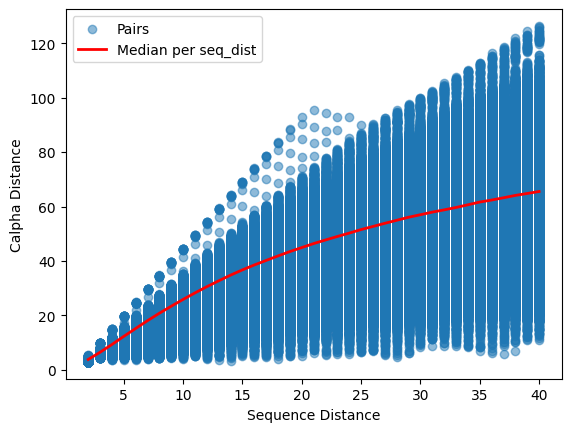

In [49]:
# Plot the relationship between sequence length and Calpha distance with median line
plt.scatter(df_dist_all['seq_dist'], df_dist_all['calpha_dist'], alpha=0.5, label='Pairs')

# Compute median calpha_dist and n_obs for each seq_dist,
# then merge 'seq_dist' and its corresponding 'median' calpha_dist into columns
median_per_seq_dist = (
    df_dist_all.groupby('seq_dist')['calpha_dist']
    .agg([('calpha_dist', 'median'), ('n_obs', 'count')])
    .reset_index()
)

# Plot the median line (median calpha_dist for each seq_dist)
plt.plot(median_per_seq_dist['seq_dist'], median_per_seq_dist['calpha_dist'],
         color='red', linewidth=2, label='Median per seq_dist')

plt.xlabel('Sequence Distance')
plt.ylabel('Calpha Distance')
plt.legend()
plt.show()

In [50]:
median_per_seq_dist.head()

,seq_dist,calpha_dist,n_obs
0,2.0,3.842313,35421
1,3.0,6.483932,31954
2,4.0,9.342919,28487
3,5.0,12.322629,25607
4,6.0,15.221287,23329


In [ ]:
# write median_per_seq_dist to csv as a reference table for grafting GS linkers
median_per_seq_dist.to_csv('median_linker_length.csv', index=False)